In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from transformers import pipeline
from transformers import AutoTokenizer, TFAutoModelForSeq2SeqLM
from transformers import DataCollatorForSeq2Seq
import evaluate
import tensorflow as tf
from tqdm import tqdm

# Task 6: Machine Translation

In this task, a machine translation model is created, which receives the dataset from Task 3 as input, uses a pre-trained model to translate from French to English language and creates a new column with the translation.

Further on, the translations will be evaluated as the image below:

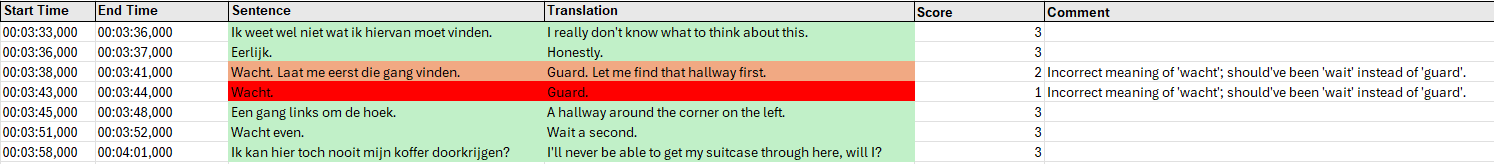

Finally, with the evalauation, the group will create a summary of the findings and categorize the type of mistakes done by the model. This can be evidenced in the Model Card.

In [2]:
raw_datasets = load_dataset("kde4", lang1="en", lang2="fr", trust_remote_code=True)

In [3]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 210173
    })
})

In [4]:
split_datasets = raw_datasets["train"].train_test_split(train_size=0.9, seed=20)
split_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 189155
    })
    test: Dataset({
        features: ['id', 'translation'],
        num_rows: 21018
    })
})

In [5]:
split_datasets["validation"] = split_datasets.pop("test")

In [6]:
split_datasets["train"][1]["translation"]

{'en': 'Default to expanded threads',
 'fr': 'Par défaut, développer les fils de discussion'}

In [7]:
model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"
translator = pipeline("translation", model=model_checkpoint)
translator("Default to expanded threads")

c:\Users\luisf\anaconda3\envs\blockc_y2\lib\site-packages\transformers\models\marian\tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0


[{'translation_text': 'Par défaut pour les threads élargis'}]

In [8]:
split_datasets["train"][172]["translation"]

{'en': 'Unable to import %1 using the OFX importer plugin. This file is not the correct format.',
 'fr': "Impossible d'importer %1 en utilisant le module d'extension d'importation OFX. Ce fichier n'a pas un format correct."}

In [9]:
model_checkpoint = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, return_tensors="pt")

In [10]:
en_sentence = split_datasets["train"][1]["translation"]["en"]
fr_sentence = split_datasets["train"][1]["translation"]["fr"]

inputs = tokenizer(en_sentence, text_target=fr_sentence)
inputs

{'input_ids': [47591, 12, 9842, 19634, 9, 0], 'attention_mask': [1, 1, 1, 1, 1, 1], 'labels': [577, 5891, 2, 3184, 16, 2542, 5, 1710, 0]}

In [11]:
wrong_targets = tokenizer(fr_sentence)
print(tokenizer.convert_ids_to_tokens(wrong_targets["input_ids"]))
print(tokenizer.convert_ids_to_tokens(inputs["labels"]))

['▁Par', '▁dé', 'f', 'aut', ',', '▁dé', 've', 'lop', 'per', '▁les', '▁fil', 's', '▁de', '▁discussion', '</s>']
['▁Par', '▁défaut', ',', '▁développer', '▁les', '▁fils', '▁de', '▁discussion', '</s>']


In [12]:
max_length = 128


def preprocess_function(examples):
    inputs = [ex["en"] for ex in examples["translation"]]
    targets = [ex["fr"] for ex in examples["translation"]]
    model_inputs = tokenizer(
        inputs, text_target=targets, max_length=max_length, truncation=True
    )
    return model_inputs

In [13]:
tokenized_datasets = split_datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=split_datasets["train"].column_names,
)

In [14]:
model = TFAutoModelForSeq2SeqLM.from_pretrained(model_checkpoint, from_pt=True)

All PyTorch model weights were used when initializing TFMarianMTModel.

All the weights of TFMarianMTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFMarianMTModel for predictions without further training.


In [15]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, return_tensors="tf")

batch = data_collator([tokenized_datasets["train"][i] for i in range(1, 3)])
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'decoder_input_ids'])

In [16]:
batch["labels"]

<tf.Tensor: shape=(2, 16), dtype=int64, numpy=
array([[  577,  5891,     2,  3184,    16,  2542,     5,  1710,     0,
         -100,  -100,  -100,  -100,  -100,  -100,  -100],
       [ 1211,     3,    49,  9409,  1211,     3, 29140,   817,  3124,
          817,   550,  7032,  5821,  7907, 12649,     0]])>

In [17]:
batch["decoder_input_ids"]

<tf.Tensor: shape=(2, 16), dtype=int64, numpy=
array([[59513,   577,  5891,     2,  3184,    16,  2542,     5,  1710,
            0, 59513, 59513, 59513, 59513, 59513, 59513],
       [59513,  1211,     3,    49,  9409,  1211,     3, 29140,   817,
         3124,   817,   550,  7032,  5821,  7907, 12649]])>

In [18]:
for i in range(1, 3):
    print(tokenized_datasets["train"][i]["labels"])

[577, 5891, 2, 3184, 16, 2542, 5, 1710, 0]
[1211, 3, 49, 9409, 1211, 3, 29140, 817, 3124, 817, 550, 7032, 5821, 7907, 12649, 0]


In [19]:
tf_train_dataset = model.prepare_tf_dataset(
    tokenized_datasets["train"],
    collate_fn=data_collator,
    shuffle=True,
    batch_size=32,
)
tf_eval_dataset = model.prepare_tf_dataset(
    tokenized_datasets["validation"],
    collate_fn=data_collator,
    shuffle=False,
    batch_size=16,
)

In [20]:
metric = evaluate.load("sacrebleu")

In [21]:
predictions = [
    "This plugin lets you translate web pages between several languages automatically."
]
references = [
    [
        "This plugin allows you to automatically translate web pages between several languages."
    ]
]
metric.compute(predictions=predictions, references=references)

{'score': 46.750469682990165,
 'counts': [11, 6, 4, 3],
 'totals': [12, 11, 10, 9],
 'precisions': [91.66666666666667,
  54.54545454545455,
  40.0,
  33.333333333333336],
 'bp': 0.9200444146293233,
 'sys_len': 12,
 'ref_len': 13}

In [22]:
generation_data_collator = DataCollatorForSeq2Seq(
    tokenizer, model=model, return_tensors="tf", pad_to_multiple_of=128
)

tf_generate_dataset = model.prepare_tf_dataset(
    tokenized_datasets["validation"],
    collate_fn=generation_data_collator,
    shuffle=False,
    batch_size=8,
)


@tf.function(jit_compile=True)
def generate_with_xla(batch):
    return model.generate(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        max_new_tokens=128,
    )


def compute_metrics():
    all_preds = []
    all_labels = []

    for batch, labels in tqdm(tf_generate_dataset):
        predictions = generate_with_xla(batch)
        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        labels = labels.numpy()
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        decoded_preds = [pred.strip() for pred in decoded_preds]
        decoded_labels = [[label.strip()] for label in decoded_labels]
        all_preds.extend(decoded_preds)
        all_labels.extend(decoded_labels)

    result = metric.compute(predictions=all_preds, references=all_labels)
    return {"bleu": result["score"]}

In [24]:
from transformers import create_optimizer
from transformers.keras_callbacks import PushToHubCallback
import tensorflow as tf

# The number of training steps is the number of samples in the dataset, divided by the batch size then multiplied
# by the total number of epochs. Note that the tf_train_dataset here is a batched tf.data.Dataset,
# not the original Hugging Face Dataset, so its len() is already num_samples // batch_size.
num_epochs = 3
num_train_steps = len(tf_train_dataset) * num_epochs

optimizer, schedule = create_optimizer(
    init_lr=5e-5,
    num_warmup_steps=0,
    num_train_steps=num_train_steps,
    weight_decay_rate=0.01,
)
model.compile(optimizer=optimizer)

# Train in mixed-precision float16
tf.keras.mixed_precision.set_global_policy("mixed_float16")

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [ ]:
model.fit(
    tf_train_dataset,
    validation_data=tf_eval_dataset,
    epochs=num_epochs
)

Epoch 1/3

  11/5911 [..............................] - ETA: 14:45:19 - loss: 1.5703

This document is a simple iteration that would use an untrained model. It was too long, so decided to make the final iteration in the machine_translation.ipynb file instead.